#### Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Parametros

In [2]:
PATH = 'C:/Users/tinch/coderhouse/template/data/processed/'

#### Lectura

In [3]:
df = pd.read_csv(f'{PATH}dataset_merged_processed.csv')

In [4]:
df.head(1)

,ID,systolic,relaxation,Cholesterol,triglyceride,HDL,LDL,gender,age,height(cm),...,serum creatinine,ALT,Gtp,dental caries,tartar,eyesight(left),eyesight(right),hearing(left),hearing(right),target
0,0,4.75,3.041667,8.958333,3.416667,3.041667,5.25,F,40.0,155.0,...,0.004861,0.791667,1.125,0,Y,0.043056,0.041667,0.041667,0.041667,0


In [5]:
df["target"] = df["target"].map({0:"NO FUMADOR", 1:"FUMADOR"})

#### EDA

In [6]:
df.describe()

,ID,systolic,relaxation,Cholesterol,triglyceride,HDL,LDL,age,height(cm),weight(kg),...,hemoglobin,Urine protein,serum creatinine,ALT,Gtp,dental caries,eyesight(left),eyesight(right),hearing(left),hearing(right)
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,26284.994580,5.062688,3.167519,8.206039,5.275309,2.387391,4.791840,44.188155,164.646278,65.877008,...,0.593798,0.045283,0.018823,1.128868,1.667899,0.213120,0.028450,0.028276,0.042737,0.042758
std,16015.070567,0.567825,0.401889,1.506033,2.980229,0.609557,1.698239,12.028283,9.172001,12.817799,...,0.065770,0.016819,0.016203,1.318034,2.104838,0.409516,0.023898,0.023940,0.006586,0.006640
min,0.000000,2.958333,1.666667,2.291667,0.333333,0.166667,0.041667,20.000000,130.000000,30.000000,...,0.172917,0.041667,0.000694,0.041667,0.041667,0.000000,0.000694,0.000694,0.041667,0.041667
25%,12499.750000,4.666667,2.916667,7.166667,3.083333,1.958333,3.833333,40.000000,160.000000,55.000000,...,0.545833,0.041667,0.005556,0.625000,0.708333,0.000000,0.005556,0.005556,0.041667,0.041667
50%,24999.500000,5.000000,3.166667,8.166667,4.500000,2.333333,4.750000,40.000000,165.000000,65.000000,...,0.588889,0.041667,0.018823,0.875000,1.083333,0.000000,0.041667,0.041667,0.041667,0.041667
75%,40034.250000,5.416667,3.416667,9.125000,6.666667,2.708333,5.625000,55.000000,170.000000,75.000000,...,0.629861,0.041667,0.041667,1.291667,1.833333,0.000000,0.043056,0.043056,0.041667,0.041667
max,55690.000000,10.000000,6.083333,18.541667,41.625000,25.750000,77.500000,85.000000,190.000000,135.000000,...,0.875694,0.250000,0.462500,121.416667,41.625000,1.000000,0.381250,0.381250,0.083333,0.083333


In [7]:
target_counts = df.target.value_counts(normalize=True)*100

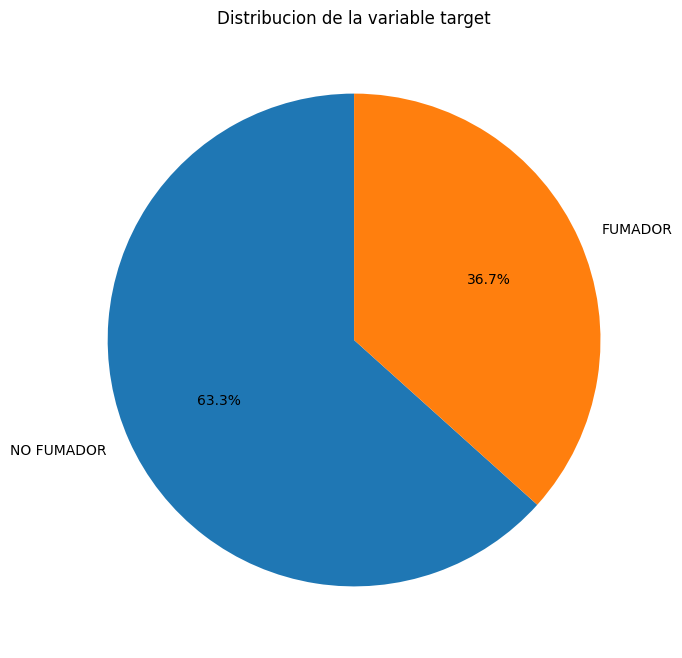

In [8]:
plt.figure(figsize=(8,8))
plt.pie(target_counts, labels=target_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Distribucion de la variable target")
plt.show()

In [9]:
object_columns = df.select_dtypes(include=["object"]).columns

C:\Users\tinch\AppData\Local\Temp\ipykernel_27488\3745126527.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include=["object"]).columns


In [10]:
object_columns = object_columns.drop("target")

In [11]:
object_columns

Index(['gender', 'tartar'], dtype='str')

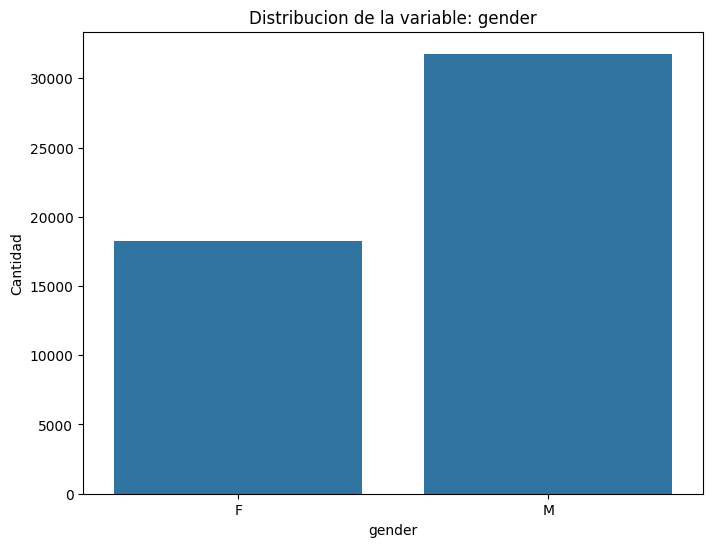

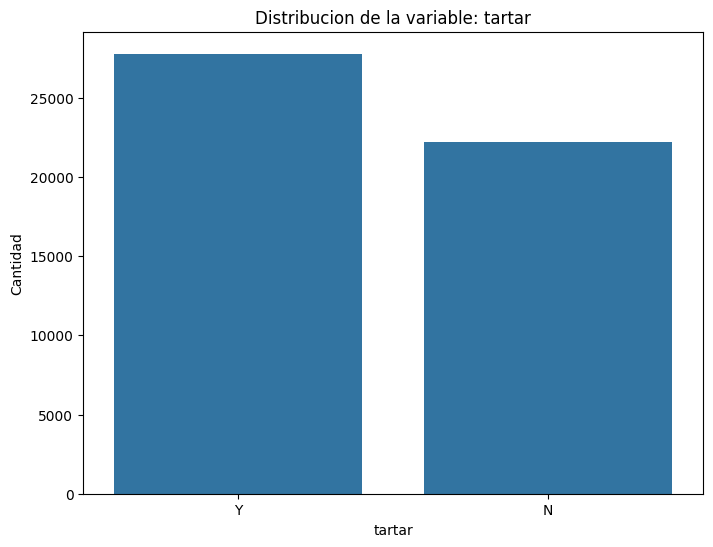

In [12]:
for column in object_columns:
    plt.figure(figsize=(8,6))
    sns.countplot(data=df, x=column)
    plt.title(f"Distribucion de la variable: {column}")
    plt.xlabel(column)
    plt.ylabel("Cantidad")
    plt.show()

In [13]:
df.tartar.value_counts()

tartar
Y    27789
N    22211
Name: count, dtype: int64

In [14]:
df.gender.value_counts()

gender
M    31776
F    18224
Name: count, dtype: int64

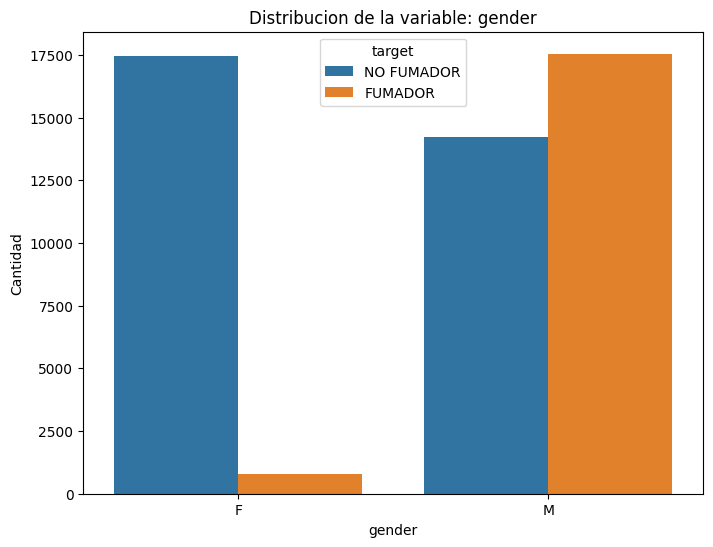

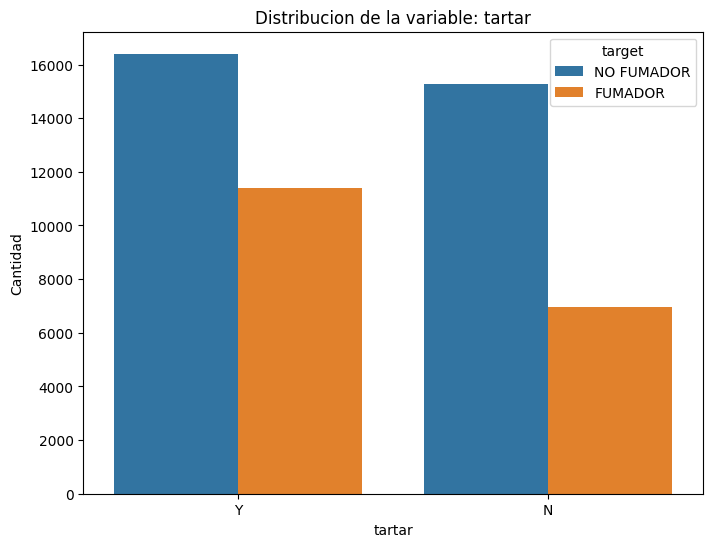

In [15]:
for column in object_columns:
    plt.figure(figsize=(8,6))
    sns.countplot(data=df, x=column, hue="target")
    plt.title(f"Distribucion de la variable: {column}")
    plt.xlabel(column)
    plt.ylabel("Cantidad")
    plt.show()

In [16]:
df.describe()

,ID,systolic,relaxation,Cholesterol,triglyceride,HDL,LDL,age,height(cm),weight(kg),...,hemoglobin,Urine protein,serum creatinine,ALT,Gtp,dental caries,eyesight(left),eyesight(right),hearing(left),hearing(right)
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,26284.994580,5.062688,3.167519,8.206039,5.275309,2.387391,4.791840,44.188155,164.646278,65.877008,...,0.593798,0.045283,0.018823,1.128868,1.667899,0.213120,0.028450,0.028276,0.042737,0.042758
std,16015.070567,0.567825,0.401889,1.506033,2.980229,0.609557,1.698239,12.028283,9.172001,12.817799,...,0.065770,0.016819,0.016203,1.318034,2.104838,0.409516,0.023898,0.023940,0.006586,0.006640
min,0.000000,2.958333,1.666667,2.291667,0.333333,0.166667,0.041667,20.000000,130.000000,30.000000,...,0.172917,0.041667,0.000694,0.041667,0.041667,0.000000,0.000694,0.000694,0.041667,0.041667
25%,12499.750000,4.666667,2.916667,7.166667,3.083333,1.958333,3.833333,40.000000,160.000000,55.000000,...,0.545833,0.041667,0.005556,0.625000,0.708333,0.000000,0.005556,0.005556,0.041667,0.041667
50%,24999.500000,5.000000,3.166667,8.166667,4.500000,2.333333,4.750000,40.000000,165.000000,65.000000,...,0.588889,0.041667,0.018823,0.875000,1.083333,0.000000,0.041667,0.041667,0.041667,0.041667
75%,40034.250000,5.416667,3.416667,9.125000,6.666667,2.708333,5.625000,55.000000,170.000000,75.000000,...,0.629861,0.041667,0.041667,1.291667,1.833333,0.000000,0.043056,0.043056,0.041667,0.041667
max,55690.000000,10.000000,6.083333,18.541667,41.625000,25.750000,77.500000,85.000000,190.000000,135.000000,...,0.875694,0.250000,0.462500,121.416667,41.625000,1.000000,0.381250,0.381250,0.083333,0.083333


#### Distribuciones

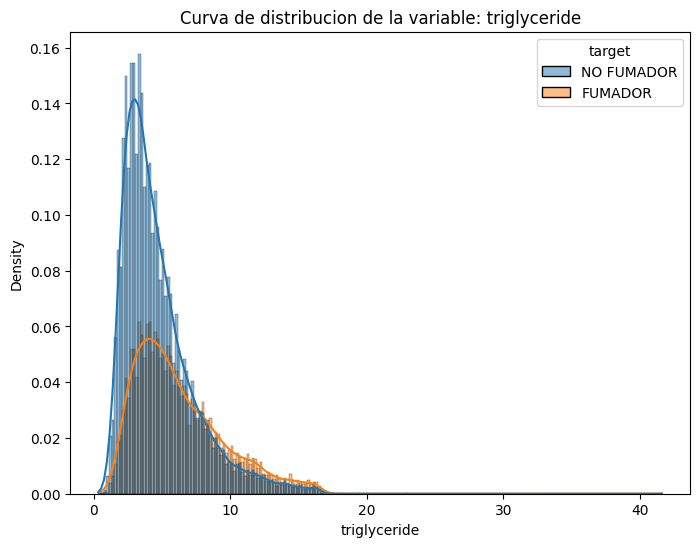

In [20]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x = "triglyceride", kde=True, hue="target", stat="density")
plt.title("Curva de distribucion de la variable: triglyceride")
plt.show()

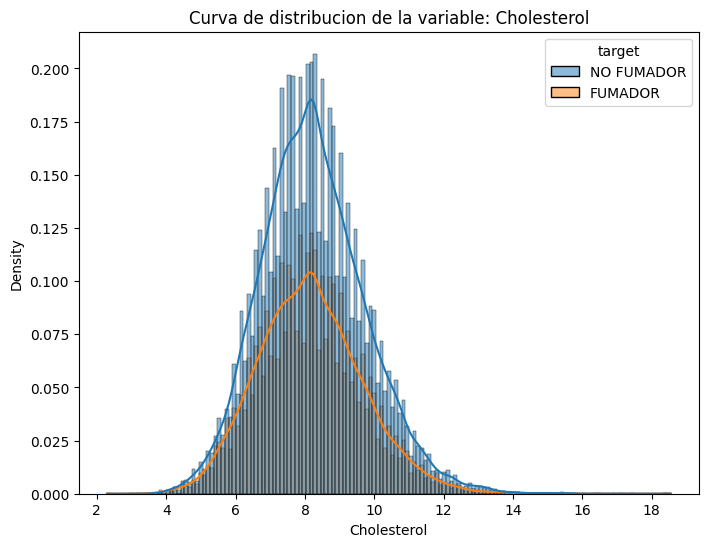

In [32]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x = "Cholesterol", kde=True, hue="target", stat="density")
plt.title("Curva de distribucion de la variable: Cholesterol")
plt.show()

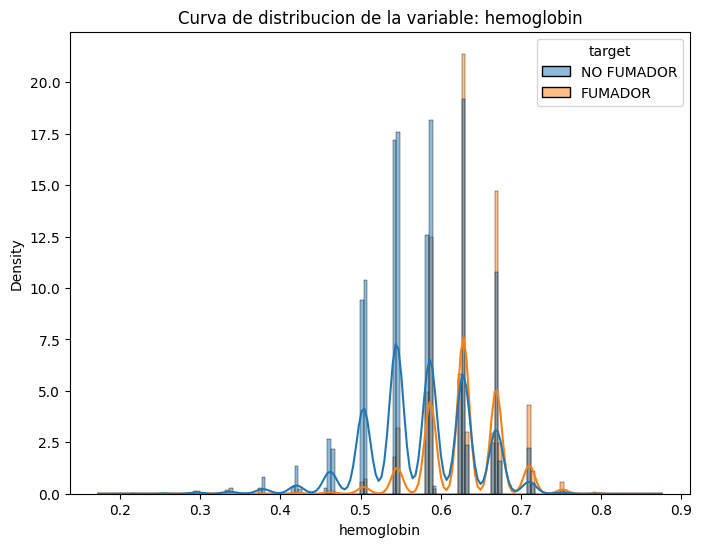

In [33]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x = "hemoglobin", kde=True, hue="target", stat="density")
plt.title("Curva de distribucion de la variable: hemoglobin")
plt.show()

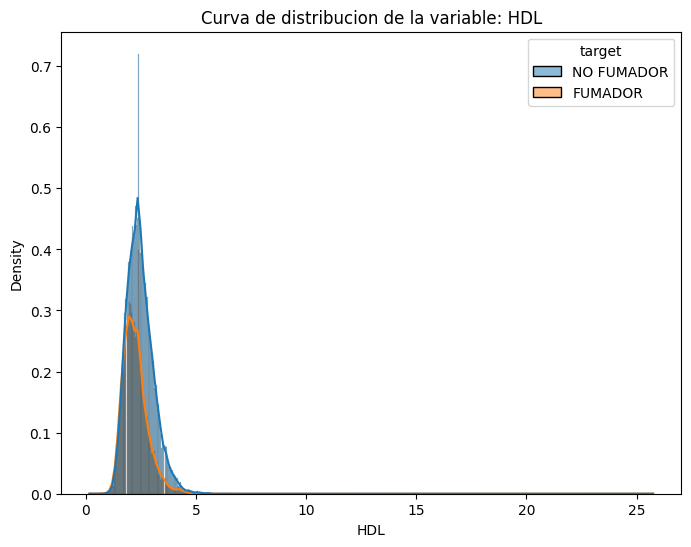

In [37]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x = "HDL", kde=True, hue="target", stat="density")
plt.title("Curva de distribucion de la variable: HDL")
plt.show()

#### Boxplots

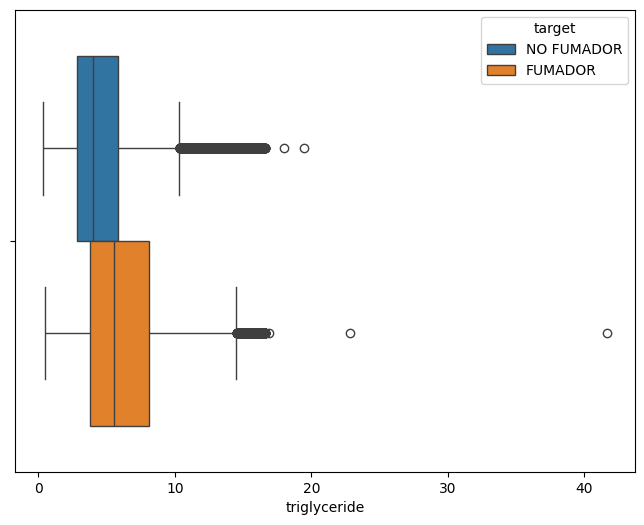

In [34]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x = "triglyceride", hue="target")
plt.show()

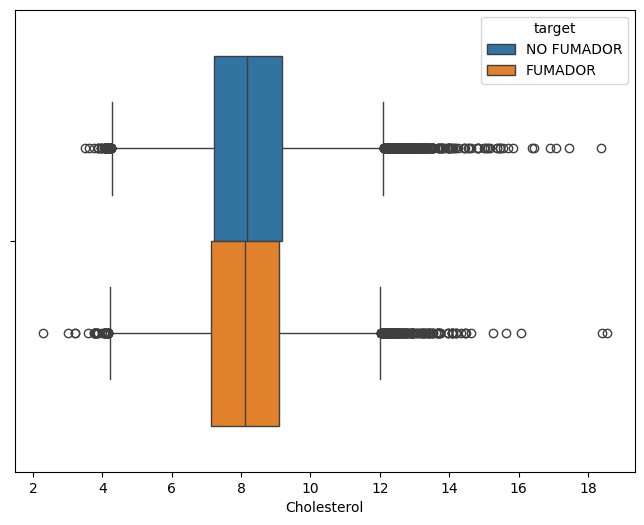

In [38]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x = "Cholesterol", hue="target")
plt.show()

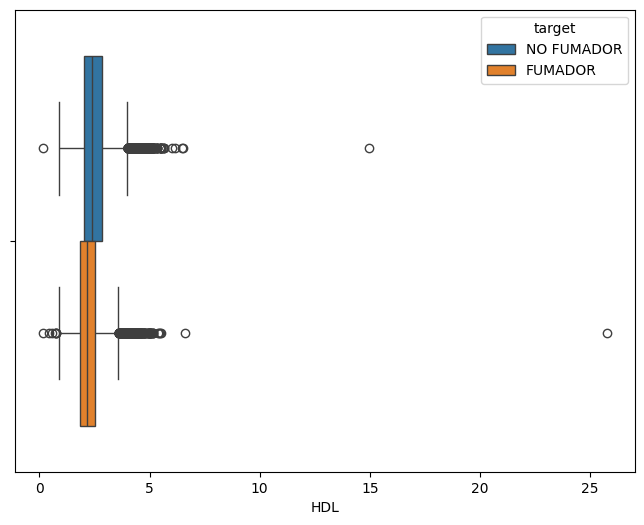

In [35]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x = "HDL", hue="target")
plt.show()

#### Scatterplots

In [39]:
df.columns

Index(['ID', 'systolic', 'relaxation', 'Cholesterol', 'triglyceride', 'HDL',
       'LDL', 'gender', 'age', 'height(cm)', 'weight(kg)', 'waist(cm)',
       'fasting blood sugar', 'hemoglobin', 'Urine protein',
       'serum creatinine', 'ALT', 'Gtp', 'dental caries', 'tartar',
       'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)',
       'target'],
      dtype='str')

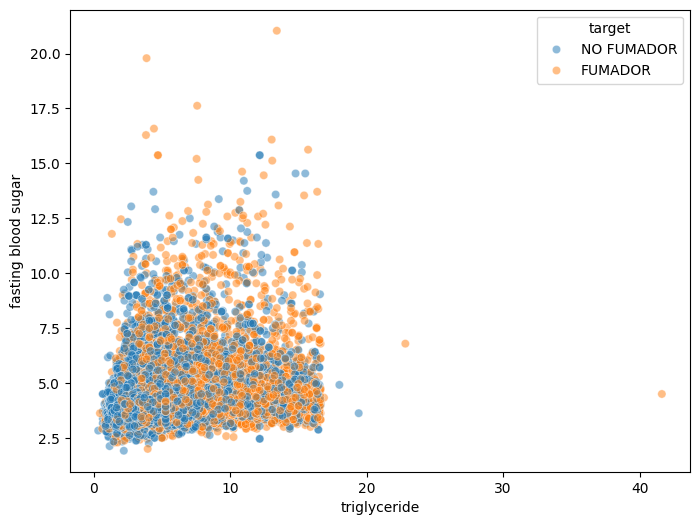

In [44]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x = "triglyceride", y="fasting blood sugar", hue="target", alpha=0.5)
plt.show()

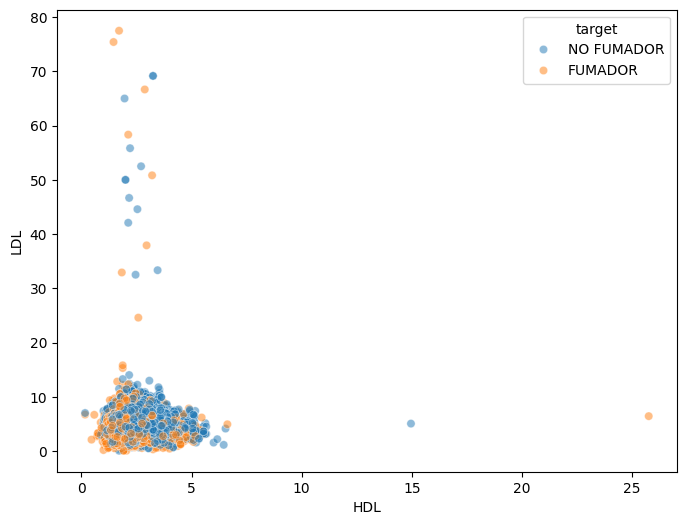

In [46]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x = "HDL", y="LDL", hue="target", alpha=0.5)
plt.show()

#### Correlacion